<a href="https://colab.research.google.com/github/aaronhuang317/TW_Stock_ML/blob/main/Macro_Market_Trend_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Macro-Market Trend Predictor (總經與市場多維數據中期趨勢預測模型)

本專案旨在結合 **Yahoo Finance (yfinance)** 的市場即時高頻數據與**政府開源總經數據**，透過機器學習建立一個中長期（30天）的市場趨勢方向預測模型。

---

## 🚀 專案核心架構與規格 (SPEC)

### 1. 預測目標 (Target)
* **任務類型**：二元分類（Binary Classification）
* **預測標的**：未來 **30天** 市場或個股的漲跌方向（`1 = 漲`, `0 = 跌`）。
* **核心邏輯**：過濾每日短線市場雜訊，專注於中長期大趨勢。

### 2. 數據獲取與對齊 (Data Ingestion & Alignment)
* **市場資料**：透過 `yfinance` 取得日線數據。
* **降噪機制**：對價格與成交量進行 **30天區間平滑（Rolling Mean）**。
* **總經對齊**：嚴格依據政府總經數據的 **實際發布日（Release Date）** 進行對齊，杜絕任何未來資料洩漏（Look-ahead Bias）。

### 3. 特徵工程 (Feature Engineering)
* **特徵池**：國際指數、國內指數、個股類股漲幅與政府總經指標。
* **數據標準化**：全面採用 **Z-Score 標準化**，確保高震幅個股與低變動總經數據在同一數階，避免模型失衡。
* **滯後處理**：基於領域經驗設定 **靜態滯後參數（Static Lag）**，先行過濾無效特徵。

### 4. 模型驗證與訓練範圍 (Validation & Training)
* **驗證機制**：採用 **走步驗證（Walk-Forward / Rolling Window Validation）**，模擬真實市場時間推進。
* **歷史窗口**：採用 **固定最近 3 至 5 年的滾動窗口資料**，完美避開過時宏觀環境（如舊時代低利率與疫情前結構）的干擾。
* **演算法推薦**：優先採用支援表格數據的高效樹模型（如 **LightGBM** 或 **Random Forest**）。

# [Colab 專用] Vibe Coding 專案開發指引與核心架構

當你在協助我撰寫此專案的 Python 程式碼時，必須嚴格遵守以下架構與設計原則，禁止隨意更改核心邏輯或偷跑不合理的複雜架構：

## 🛠️ 開發鐵律
1. **目標對齊**：我們的預測目標是預測「未來 30 天的漲跌方向（分類 0 或 1）」。
2. **數據平滑**：`yfinance` 抓取回來的日線資料，必須先做 **30天區間平滑（Rolling Mean）**，不要直接拿原始日線去跟總經數據對齊。
3. **時間防線**：總經數據必須嚴格對齊「實際發布日」，絕對不能有 Look-ahead Bias。
4. **滾動窗口**：訓練資料集統一使用 **最近 3 至 5 年的滾動窗口**，不要把十年以上的過時歷史全部無差別塞進去。
5. **模型選擇**：優先使用 **LightGBM** 或 **Random Forest** 等支援表格數據的樹模型，避免一開始就使用過度複雜的神經網路。

# 程式集導入

導入Yfinence及Pandas

In [8]:
import yfinance as yf
!pip install yfinance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# 資料集載入

### 總體經濟指數群

黃金資料

判斷:黃金為穩定之資產通常為避險用且較少被其他物料產出而導致價格趨勢改變

/tmp/ipykernel_964/2214896683.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download("GC=F", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


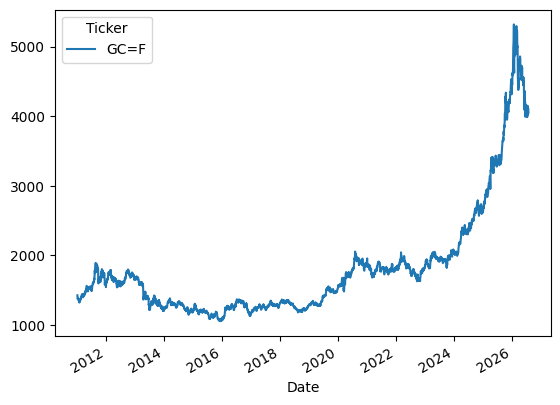

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2011-01-03,1422.599976,1423.900024,1413.699951,1415.599976,28
2011-01-04,1378.500000,1410.900024,1375.800049,1409.599976,122
2011-01-05,1373.400024,1384.000000,1364.199951,1383.400024,175
2011-01-06,1371.400024,1376.500000,1368.900024,1374.800049,158
2011-01-07,1368.500000,1377.199951,1355.500000,1372.699951,225


In [39]:
#黃金資料:gold_data  (此處為期貨價格 並取收盤價)資料區間為近15年(2011/1~2026/7)

gold_data = yf.download("GC=F", "2011-01-01" , "2026-07-31")
gold_data["Close"].plot()
plt.show()
gold_data.head()

10年美債殖利率資料

判斷:10年期美債殖利率被視為全球金融資產的定價錨點與經濟晴雨表，其高檔震盪持續牽動股市評價、借貸成本與匯率走向

/tmp/ipykernel_964/292502999.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ten_year_US_Yield = yf.download("^TNX", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


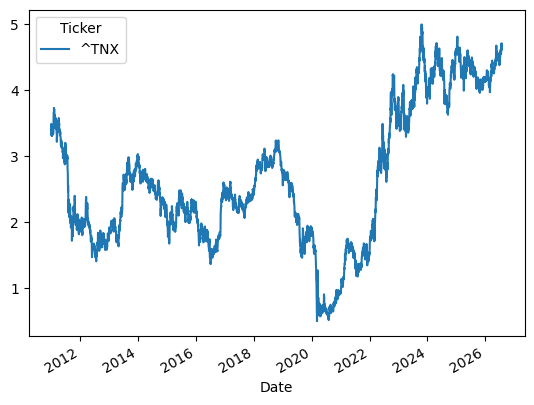

Price,Close,High,Low,Open,Volume
Ticker,^TNX,^TNX,^TNX,^TNX,^TNX
Date,,,,,
2011-01-03,3.342,3.420,3.313,3.377,0
2011-01-04,3.346,3.362,3.302,3.338,0
2011-01-05,3.483,3.497,3.379,3.381,0
2011-01-06,3.419,3.460,3.393,3.442,0
2011-01-07,3.328,3.464,3.297,3.435,0


In [40]:
#10年美債殖利率:ten_year_US_Yield  資料區間為近15年(2011/1~2026/7)

ten_year_US_Yield = yf.download("^TNX", "2011-01-01" , "2026-07-31")
ten_year_US_Yield["Close"].plot()
plt.show()
ten_year_US_Yield.head()

布倫特原油資料

判斷:布倫特原油期貨合約是布倫特原油定價體系的一部分，包括現貨及遠期合約市場。該價格體系涵蓋了世界原油交易量的65%

/tmp/ipykernel_964/3759103245.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  brent_oil = yf.download("CL=F", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


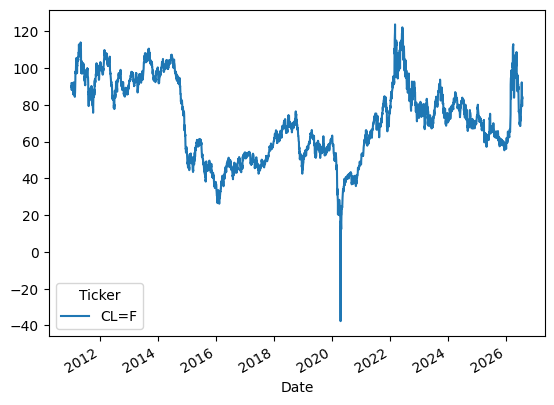

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2011-01-03,91.550003,92.580002,91.209999,91.309998,225189
2011-01-04,89.379997,92.070000,88.360001,91.500000,415521
2011-01-05,90.300003,90.839996,88.099998,89.290001,416908
2011-01-06,88.379997,90.709999,87.849998,90.470001,440456
2011-01-07,88.029999,89.480003,87.250000,88.180000,444813


In [41]:
brent_oil = yf.download("CL=F", "2011-01-01" , "2026-07-31")
brent_oil["Close"].plot()
plt.show()
brent_oil.head()

道瓊工業指數dji

/tmp/ipykernel_964/1828990209.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dji = yf.download("^DJI", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


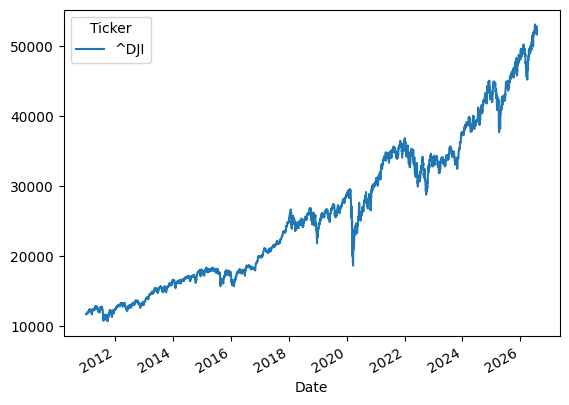

Price,Close,High,Low,Open,Volume
Ticker,^DJI,^DJI,^DJI,^DJI,^DJI
Date,,,,,
2011-01-03,11670.750000,11711.469727,11577.349609,11577.429688,203420000
2011-01-04,11691.179688,11698.219727,11635.740234,11670.900391,178630000
2011-01-05,11722.889648,11742.679688,11652.889648,11688.610352,169990000
2011-01-06,11697.309570,11736.740234,11667.459961,11716.929688,193080000
2011-01-07,11674.759766,11726.940430,11599.679688,11696.860352,188720000


In [42]:
dji = yf.download("^DJI", "2011-01-01" , "2026-07-31")
dji ["Close"].plot()
plt.show()
dji.head()

德國的法蘭克福股價指數（DAX Index）

/tmp/ipykernel_964/1324960233.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  de_stock = yf.download("^GDAXI", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


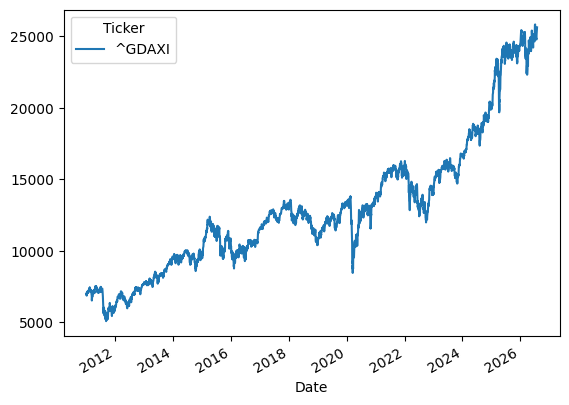

Price,Close,High,Low,Open,Volume
Ticker,^GDAXI,^GDAXI,^GDAXI,^GDAXI,^GDAXI
Date,,,,,
2011-01-03,6989.740234,7026.620117,6969.830078,6973.390137,61893200
2011-01-04,6975.350098,7025.859863,6952.020020,6979.680176,87665600
2011-01-05,6939.819824,6967.240234,6842.899902,6966.080078,117141900
2011-01-06,6981.390137,7047.589844,6949.069824,6949.479980,91236400
2011-01-07,6947.839844,7010.890137,6939.879883,6991.549805,92626900


In [43]:
de_stock = yf.download("^GDAXI", "2011-01-01" , "2026-07-31")
de_stock ["Close"].plot()
plt.show()
de_stock.head()

日經指數（Nikkei）是日本東京證交所所編製的股價指數，是國際投資人在研究日本股市時一個重要的參考指數。日經指數亦有許多不同的系列指數，如最為人所熟知的日經225（Nikkei 225）即涵蓋了東京證交所裡最具代表性的225檔股票

/tmp/ipykernel_964/1183807501.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jp_stock = yf.download("^N225", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


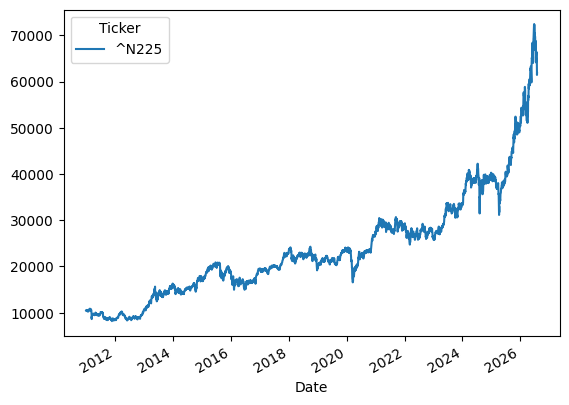

Price,Close,High,Low,Open,Volume
Ticker,^N225,^N225,^N225,^N225,^N225
Date,,,,,
2011-01-04,10398.099609,10409.169922,10321.280273,10352.190430,114100000
2011-01-05,10380.769531,10413.450195,10358.009766,10387.950195,114600000
2011-01-06,10529.759766,10530.110352,10477.519531,10477.519531,166000000
2011-01-07,10541.040039,10550.709961,10503.019531,10506.719727,161800000
2011-01-11,10510.679688,10538.389648,10476.290039,10484.620117,138500000


In [44]:
jp_stock = yf.download("^N225", "2011-01-01" , "2026-07-31")
jp_stock ["Close"].plot()
plt.show()
jp_stock.head()

S & P 500指數

/tmp/ipykernel_964/1480517336.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sap500 = yf.download("^GSPC", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


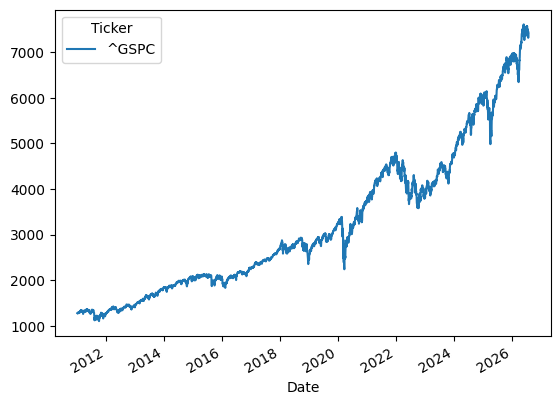

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2011-01-03,1271.869995,1276.170044,1257.619995,1257.619995,4286670000
2011-01-04,1270.199951,1274.119995,1262.660034,1272.949951,4796420000
2011-01-05,1276.560059,1277.630005,1265.359985,1268.780029,4764920000
2011-01-06,1273.849976,1278.170044,1270.430054,1276.290039,4844100000
2011-01-07,1271.500000,1276.829956,1261.699951,1274.410034,4963110000


In [45]:
sap500 = yf.download("^GSPC", "2011-01-01" , "2026-07-31")
sap500 ["Close"].plot()
plt.show()
sap500.head()

VIX 指數（CBOE Volatility Index），俗稱「恐慌指數」，是芝加哥期權交易所用來衡量美國股市（S&P 500 指數）未來 30 天預期波動程度的指標。它反映了市場投資人對於未來股市風險與不確定性的心理預期。

/tmp/ipykernel_964/3007887241.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix  = yf.download("^VIX", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


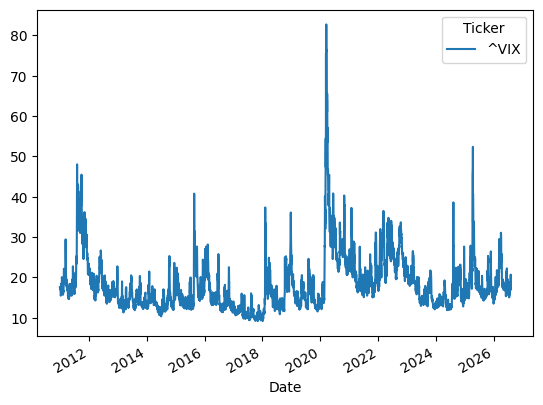

Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2011-01-03,17.610001,17.950001,16.910000,17.940001,0
2011-01-04,17.379999,18.240000,17.330000,17.340000,0
2011-01-05,17.020000,17.950001,16.860001,17.809999,0
2011-01-06,17.400000,17.559999,16.790001,16.799999,0
2011-01-07,17.139999,18.070000,16.570000,17.309999,0


In [46]:
vix  = yf.download("^VIX", "2011-01-01" , "2026-07-31")
vix  ["Close"].plot()
plt.show()
vix.head()


NASDAQ Composite(^IXIC) 走勢圖


/tmp/ipykernel_964/1130438141.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq  = yf.download("^IXIC", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


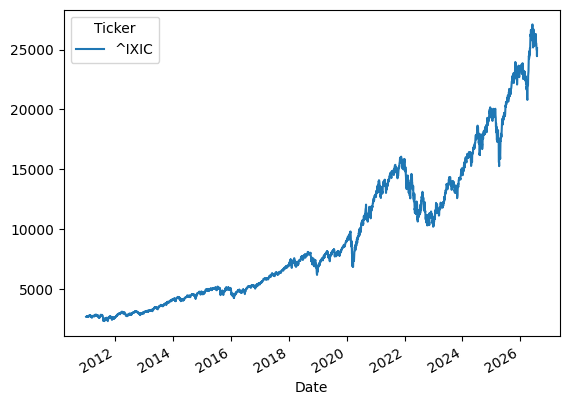

Price,Close,High,Low,Open,Volume
Ticker,^IXIC,^IXIC,^IXIC,^IXIC,^IXIC
Date,,,,,
2011-01-03,2691.520020,2704.860107,2676.340088,2676.649902,1919660000
2011-01-04,2681.250000,2700.879883,2663.639893,2699.860107,2015440000
2011-01-05,2702.199951,2702.199951,2671.889893,2673.909912,2060750000
2011-01-06,2709.889893,2712.350098,2697.729980,2704.379883,2095490000
2011-01-07,2703.169922,2715.959961,2676.360107,2712.750000,1976220000


In [47]:
nasdaq  = yf.download("^IXIC", "2011-01-01" , "2026-07-31")
nasdaq  ["Close"].plot()
plt.show()
nasdaq.head()

台股加權指數

/tmp/ipykernel_964/49362686.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  twii  = yf.download("^TWII", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


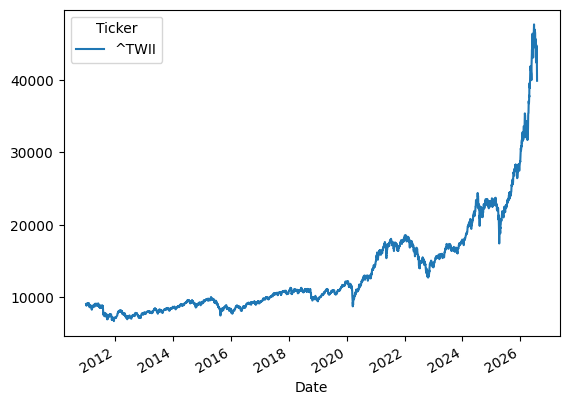

Price,Close,High,Low,Open,Volume
Ticker,^TWII,^TWII,^TWII,^TWII,^TWII
Date,,,,,
2011-01-03,9025.258789,9041.279224,8994.459124,9039.588802,5067400
2011-01-04,8997.149414,9046.138449,8988.539102,9045.069117,5270400
2011-01-05,8846.269531,9027.119299,8812.320466,9014.279513,5796600
2011-01-06,8883.168945,8883.168945,8813.589188,8866.189532,4362200
2011-01-07,8782.679688,8907.069745,8738.889848,8905.209402,4500800


In [50]:
twii  = yf.download("^TWII", "2011-01-01" , "2026-07-31")
twii  ["Close"].plot()
plt.show()
twii.head()

美國CPI(美國消費者物價指數)年增率(YoY)

原始 CPI 指數去計算 YoY（公式：$\frac{\text{CPI}_t}{\text{CPI}_{t-12}} - 1$）：

/tmp/ipykernel_964/2819328672.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi_raw["CPI_YoY"] = cpi_raw["CPIAUCSL"].pct_change(12) * 100


=== 最終檢查 ===
資料總筆數: 4065
是否存在任何 NaN: False

首 5 筆資料:
             CPI_YoY
Date                
2011-01-03  1.700783
2011-01-04  1.700783
2011-01-05  1.700783
2011-01-06  1.700783
2011-01-07  1.700783

末 5 筆資料:
             CPI_YoY
Date                
2026-07-27  3.463531
2026-07-28  3.463531
2026-07-29  3.463531
2026-07-30  3.463531
2026-07-31  3.463531


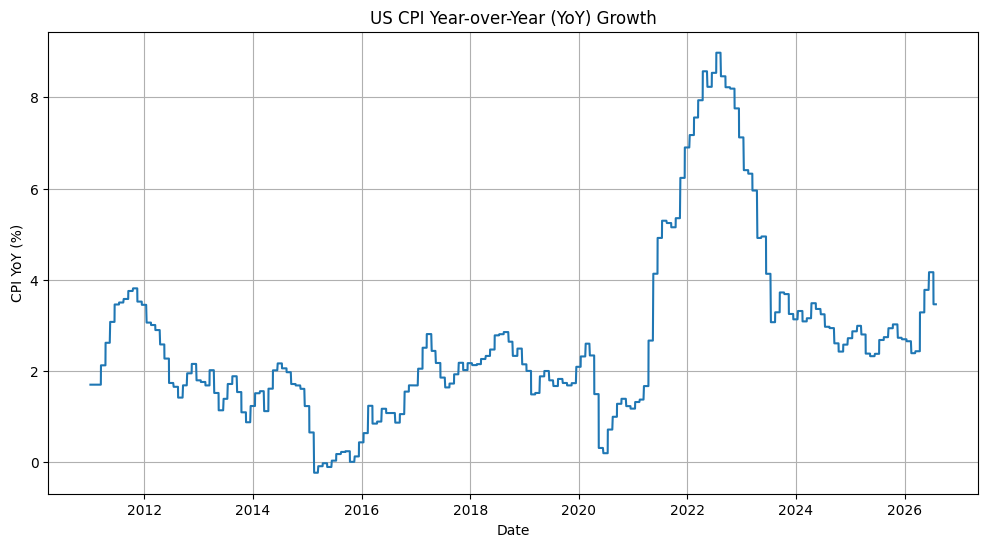

,CPI_YoY
Date,
2011-01-03,1.700783
2011-01-04,1.700783
2011-01-05,1.700783
2011-01-06,1.700783
2011-01-07,1.700783


In [55]:
#總經數據無法從yfinance上下載 從美國FRED抓取
import pandas_datareader.data as web
import datetime

# 設定時間範圍
start_cpi = datetime.datetime(2010, 1, 1)
end_cpi = datetime.datetime(2026, 7, 31)
# 1. 抓取資料
cpi_raw = web.DataReader("CPIAUCSL", "fred", start_cpi, end_cpi)
cpi_raw.index.name = "Date"

# 計算 YoY 並切除前 12 個月（切除後資料剛好從 2011-01-01 開始）
cpi_raw["CPI_YoY"] = cpi_raw["CPIAUCSL"].pct_change(12) * 100
cpi_df = cpi_raw.iloc[12:].copy()

# 2. 模擬實際發布日（推遲 1 個月又 14 天，即次月 15 號發布）
# 如果你的 Date 欄位本身已經是發布日，可直接將此行註解掉
cpi_df['Release_Date'] = cpi_df.index + pd.DateOffset(months=1, days=14)
cpi_df = cpi_df.reset_index().set_index('Release_Date')[['CPI_YoY']]

# 3. 建立目標日線框架（對應 yfinance 的台美股營業日，頻率設為 'B'）
daily_idx = pd.date_range(start="2011-01-01", end="2026-07-31", freq="B")
daily_df = pd.DataFrame(index=daily_idx)
daily_df.index.name = "Date"

# 4. 轉換格式以進行 merge_asof 安全對齊
daily_df = daily_df.reset_index()
cpi_df = cpi_df.reset_index()

# 嚴格向後對齊（direction='backward'），確保絕不洩漏未來資料
final_cpi_daily = pd.merge_asof(
    daily_df,
    cpi_df,
    left_on="Date",
    right_on="Release_Date",
    direction="backward"
)

# 5. 清理欄位並確保零 NaN
final_cpi_daily = final_cpi_daily.set_index("Date")[['CPI_YoY']]

# 執行雙向填補：ffill 確保日常發布空白處被填滿，bfill 確保 2011 年初極少數可能因假日產生的空缺被補齊
final_cpi_daily = final_cpi_daily.ffill().bfill()

# --- 驗證結果 ---
print("=== 最終檢查 ===")
print(f"資料總筆數: {len(final_cpi_daily)}")
print(f"是否存在任何 NaN: {final_cpi_daily.isna().any().values[0]}")
print("\n首 5 筆資料:")
print(final_cpi_daily.head())
print("\n末 5 筆資料:")
print(final_cpi_daily.tail())


plt.figure(figsize=(12, 6))
plt.plot(final_cpi_daily.index, final_cpi_daily['CPI_YoY'])
plt.title('US CPI Year-over-Year (YoY) Growth')
plt.xlabel('Date')
plt.ylabel('CPI YoY (%)')
plt.grid(True)
plt.show()

final_cpi_daily.head()

In [58]:
# 合併所有數據到一個 DataFrame，使用原始的 'Close' 價格（不平滑），以及 CPI_YoY

# 初始化合併的 DataFrame，以一個數據集的索引為基礎
yf_macroeconomics = pd.DataFrame(index=gold_data.index)

# 合併黃金數據的 'Close' 價格
gold_close = gold_data['Close']
gold_close.name = 'Gold_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, gold_close], axis=1)

# 合併10年美債殖利率數據的 'Close' 價格
us10y_yield_close = ten_year_US_Yield['Close']
us10y_yield_close.name = 'US10Y_Yield_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, us10y_yield_close], axis=1)

# 合併布倫特原油數據的 'Close' 價格
brent_oil_close = brent_oil['Close']
brent_oil_close.name = 'Brent_Oil_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, brent_oil_close], axis=1)

# 合併道瓊工業指數數據的 'Close' 價格
dji_close = dji['Close']
dji_close.name = 'DJI_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, dji_close], axis=1)

# 合併德國法蘭克福股價指數數據的 'Close' 價格
de_stock_close = de_stock['Close']
de_stock_close.name = 'DAX_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, de_stock_close], axis=1)

# 合併日經指數數據的 'Close' 價格
jp_stock_close = jp_stock['Close']
jp_stock_close.name = 'Nikkei_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, jp_stock_close], axis=1)

# 合併S&P 500指數數據的 'Close' 價格
sap500_close = sap500['Close']
sap500_close.name = 'SP500_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, sap500_close], axis=1)

# 合併VIX指數數據的 'Close' 價格
vix_close = vix['Close']
vix_close.name = 'VIX_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, vix_close], axis=1)

# 合併NASDAQ綜合指數數據的 'Close' 價格
nasdaq_close = nasdaq['Close']
nasdaq_close.name = 'NASDAQ_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, nasdaq_close], axis=1)

# 合併台灣加權指數數據的 'Close' 價格
twii_close = twii['Close']
twii_close.name = 'TWII_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, twii_close], axis=1)

# 合併 CPI YoY 數據 (該數據已經過預處理並按日對齊)
cpi_yoy_series = final_cpi_daily['CPI_YoY']
cpi_yoy_series.name = 'CPI_YoY'
yf_macroeconomics = pd.concat([yf_macroeconomics, cpi_yoy_series], axis=1)

# 顯示合併後的數據的前幾行和數據類型資訊
print("合併後的數據 (yf_macroeconomics) 的前5行：")
display(yf_macroeconomics.head())
print("合併後的數據 (yf_macroeconomics) 的基本資訊：")
yf_macroeconomics.info()

合併後的數據 (yf_macroeconomics) 的前5行：


,GC=F,^TNX,CL=F,^DJI,^GDAXI,^N225,^GSPC,^VIX,^IXIC,^TWII,CPI_YoY
Date,,,,,,,,,,,
2011-01-03,1422.599976,3.342,91.550003,11670.750000,6989.740234,NaN,1271.869995,17.610001,2691.520020,9025.258789,1.700783
2011-01-04,1378.500000,3.346,89.379997,11691.179688,6975.350098,10398.099609,1270.199951,17.379999,2681.250000,8997.149414,1.700783
2011-01-05,1373.400024,3.483,90.300003,11722.889648,6939.819824,10380.769531,1276.560059,17.020000,2702.199951,8846.269531,1.700783
2011-01-06,1371.400024,3.419,88.379997,11697.309570,6981.390137,10529.759766,1273.849976,17.400000,2709.889893,8883.168945,1.700783
2011-01-07,1368.500000,3.328,88.029999,11674.759766,6947.839844,10541.040039,1271.500000,17.139999,2703.169922,8782.679688,1.700783


合併後的數據 (yf_macroeconomics) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4065 entries, 2011-01-03 to 2026-07-31
Freq: B
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   GC=F     3915 non-null   float64
 1   ^TNX     3915 non-null   float64
 2   CL=F     3916 non-null   float64
 3   ^DJI     3914 non-null   float64
 4   ^GDAXI   3948 non-null   float64
 5   ^N225    3808 non-null   float64
 6   ^GSPC    3916 non-null   float64
 7   ^VIX     3917 non-null   float64
 8   ^IXIC    3914 non-null   float64
 9   ^TWII    3795 non-null   float64
 10  CPI_YoY  4065 non-null   float64
dtypes: float64(11)
memory usage: 381.1 KB


In [60]:
# 對 yf_macroeconomics 中的數據進行平滑化處理
yf_macroeconomics_smoothed = pd.DataFrame(index=yf_macroeconomics.index)

# 遍歷 yf_macroeconomics 的每一列
for column in yf_macroeconomics.columns:
    if column == 'CPI_YoY':
        # CPI_YoY 已經是處理過的總經數據，不進行額外平滑
        yf_macroeconomics_smoothed[column] = yf_macroeconomics[column]
    else:
        # 對其他金融數據進行30天滾動平均平滑
        yf_macroeconomics_smoothed[column] = yf_macroeconomics[column].rolling(window=30, min_periods=1).mean()


print("平滑化處理後的數據 (yf_macroeconomics_smoothed) 的前5行：")
display(yf_macroeconomics_smoothed.head())
print("平滑化處理後的數據 (yf_macroeconomics_smoothed) 的基本資訊：")
yf_macroeconomics_smoothed.info()

平滑化處理後的數據 (yf_macroeconomics_smoothed) 的前5行：


,GC=F,^TNX,CL=F,^DJI,^GDAXI,^N225,^GSPC,^VIX,^IXIC,^TWII,CPI_YoY
Date,,,,,,,,,,,
2011-01-03,1422.599976,3.342000,91.550003,11670.750000,6989.740234,NaN,1271.869995,17.610001,2691.520020,9025.258789,1.700783
2011-01-04,1400.549988,3.344000,90.465000,11680.964844,6982.545166,10398.099609,1271.034973,17.495000,2686.385010,9011.204102,1.700783
2011-01-05,1391.500000,3.390333,90.410001,11694.939779,6968.303385,10389.434570,1272.876668,17.336667,2691.656657,8956.225911,1.700783
2011-01-06,1386.475006,3.397500,89.902500,11695.532227,6971.575073,10436.209635,1273.119995,17.352500,2696.214966,8937.961670,1.700783
2011-01-07,1382.880005,3.383600,89.528000,11691.377734,6966.828027,10462.417236,1272.795996,17.310000,2697.605957,8906.905273,1.700783


平滑化處理後的數據 (yf_macroeconomics_smoothed) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4065 entries, 2011-01-03 to 2026-07-31
Freq: B
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   GC=F     4065 non-null   float64
 1   ^TNX     4065 non-null   float64
 2   CL=F     4065 non-null   float64
 3   ^DJI     4065 non-null   float64
 4   ^GDAXI   4065 non-null   float64
 5   ^N225    4064 non-null   float64
 6   ^GSPC    4065 non-null   float64
 7   ^VIX     4065 non-null   float64
 8   ^IXIC    4065 non-null   float64
 9   ^TWII    4065 non-null   float64
 10  CPI_YoY  4065 non-null   float64
dtypes: float64(11)
memory usage: 381.1 KB


### 台灣個股群

/tmp/ipykernel_964/977090110.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsmc  = yf.download("2330.TW", "2011-01-01" , "2026-07-31")
[*********************100%***********************]  1 of 1 completed


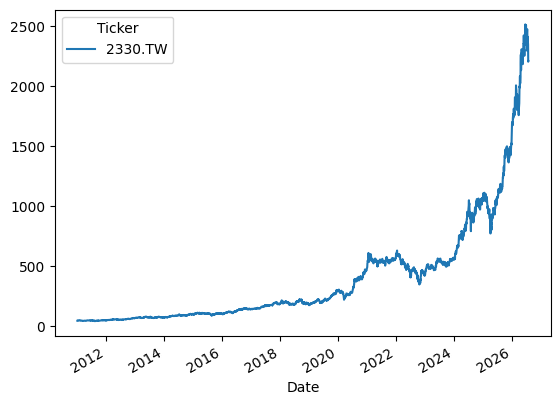

Price,Close,High,Low,Open,Volume
Ticker,^TWII,^TWII,^TWII,^TWII,^TWII
Date,,,,,
2011-01-03,9025.258789,9041.279224,8994.459124,9039.588802,5067400
2011-01-04,8997.149414,9046.138449,8988.539102,9045.069117,5270400
2011-01-05,8846.269531,9027.119299,8812.320466,9014.279513,5796600
2011-01-06,8883.168945,8883.168945,8813.589188,8866.189532,4362200
2011-01-07,8782.679688,8907.069745,8738.889848,8905.209402,4500800


In [68]:
tsmc  = yf.download("2330.TW", "2011-01-01" , "2026-07-31")
tsmc  ["Close"].plot()
plt.show()
twii.head()

In [67]:
# 定義你的各產業龍頭清單 (Yahoo Finance 代號格式)
sector_leaders = {
    "TSMC": "2330.TW",   # 半導體
    "MediaTek": "2454.TW", # IC設計
    "Delta": "2308.TW",    # 電源/散熱
    "HonHai": "2317.TW",   # 電子代工
    "Quanta": "2382.TW",   # 伺服器/廣達
    "FubonFin": "2881.TW", # 金融
    "Chunghwa": "2412.TW", # 電信
    "Evergreen": "2603.TW" # 航運
}

start_date = "2011-01-01"
end_date = "2026-07-31"

# 1. 批次抓取收盤價 (Adj.Close)
symbols_tw_stock = list(sector_leaders.values())
prices_tw_stock = yf.download(symbols_tw_stock, start=start_date, end=end_date)["Close"]


# 2. 【核心套用】：30天區間平滑 (Rolling Mean) 濾除短線雜訊
smoothed_tw_price = prices_tw_stock.rolling(window=30, min_periods=30).mean()

# 3. 【核心套用】：Z-Score 標準化 (讓不同股價級距的個股拉到同一刻度)
# 公式: (x - mean) / std
z_scored_df = (smoothed_tw_price - smoothed_tw_price.mean()) / smoothed_tw_price.std()

# 4. 刪除因為 30 天滾動產生的前端 NaN
features_df = z_scored_df.dropna()

print("=== 個股多維特徵處理完成 ===")
print(f"資料形狀 (Rows, Columns): {features_df.shape}")
print(features_df.tail())



/tmp/ipykernel_964/836664651.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices_tw_stock = yf.download(symbols_tw_stock, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  8 of 8 completed

=== 個股多維特徵處理完成 ===
資料形狀 (Rows, Columns): (3772, 8)
Ticker       2308.TW   2317.TW   2330.TW   2382.TW   2412.TW   2454.TW  \
Date                                                                     
2026-07-24  5.444429  3.351894  4.585262  3.154685  2.330541  6.263061   
2026-07-27  5.397089  3.351917  4.588283  3.141076  2.331805  6.234960   
2026-07-28  5.331801  3.336813  4.581108  3.124890  2.333095  6.168226   
2026-07-29  5.255441  3.320005  4.566003  3.109955  2.332342  6.086443   
2026-07-30  5.189467  3.295971  4.552408  3.078764  2.332934  6.015566   

Ticker       2603.TW   2881.TW  
Date                            
2026-07-24  2.363701  3.986961  
2026-07-27  2.359315  4.004603  
2026-07-28  2.354789  4.007814  
2026-07-29  2.353135  4.000953  
2026-07-30  2.356994  3.990587  
